<a href="https://colab.research.google.com/github/SmitPatil2004/traffic-forecasting-uct/blob/main/notebooks/02_traffic_modelling_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Step 1 — Set up and reload the data**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set_style('whitegrid')

df = pd.read_csv('train_aWnotuB.csv')     # ← your filename
df['DateTime'] = pd.to_datetime(df['DateTime'])
df = df.sort_values('DateTime').reset_index(drop=True)

print(df.shape)
df.head()

(48120, 4)


,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 00:00:00,2,6,20151101002
2,2015-11-01 00:00:00,3,9,20151101003
3,2015-11-01 01:00:00,3,7,20151101013
4,2015-11-01 01:00:00,1,13,20151101011


**Step 2 — Rebuild the features**

In [ ]:
df['Hour']      = df['DateTime'].dt.hour
df['DayOfWeek'] = df['DateTime'].dt.dayofweek
df['Month']     = df['DateTime'].dt.month
df['Year']      = df['DateTime'].dt.year
df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)

FEATURES = ['Junction', 'Hour', 'DayOfWeek', 'Month', 'Year', 'IsWeekend']
TARGET = 'Vehicles'

df[FEATURES + [TARGET]].head()

,Junction,Hour,DayOfWeek,Month,Year,IsWeekend,Vehicles
0,1,0,6,11,2015,1,15
1,2,0,6,11,2015,1,6
2,3,0,6,11,2015,1,9
3,3,1,6,11,2015,1,7
4,1,1,6,11,2015,1,13


 **Step 3 — Split chronologically**

In [ ]:
cutoff = df['DateTime'].quantile(0.80)
print('Cutoff date:', cutoff)

train = df[df['DateTime'] <  cutoff].copy()
test  = df[df['DateTime'] >= cutoff].copy()

print('Train:', train.shape[0], 'rows |', train['DateTime'].min().date(), '→', train['DateTime'].max().date())
print('Test: ', test.shape[0],  'rows |', test['DateTime'].min().date(),  '→', test['DateTime'].max().date())

Cutoff date: 2017-03-22 17:12:00
Train: 38496 rows | 2015-11-01 → 2017-03-22
Test:  9624 rows | 2017-03-22 → 2017-06-30


In [ ]:
X_train, y_train = train[FEATURES], train[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]

print('X_train:', X_train.shape, '| X_test:', X_test.shape)

X_train: (38496, 6) | X_test: (9624, 6)


**Step 4 — Build the baseline**

In [ ]:
def scores(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

# "Historical average for this junction at this hour"
lookup = train.groupby(['Junction', 'Hour'])[TARGET].mean()
baseline_pred = pd.MultiIndex.from_frame(test[['Junction', 'Hour']]).map(lookup)
baseline_pred = pd.Series(baseline_pred).fillna(train[TARGET].mean()).values

b_mae, b_rmse = scores(y_test, baseline_pred)
print(f'Baseline  → MAE: {b_mae:.2f} | RMSE: {b_rmse:.2f}')

Baseline  → MAE: 12.02 | RMSE: 18.68


**Step 5 — Train the Random Forest**

In [ ]:
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

pred = model.predict(X_test)

m_mae, m_rmse = scores(y_test, pred)
print(f'Baseline      → MAE: {b_mae:.2f} | RMSE: {b_rmse:.2f}')
print(f'Random Forest → MAE: {m_mae:.2f} | RMSE: {m_rmse:.2f}')
print(f'\nImprovement in MAE: {(1 - m_mae / b_mae) * 100:.1f}%')

Baseline      → MAE: 12.02 | RMSE: 18.68
Random Forest → MAE: 4.81 | RMSE: 7.89

Improvement in MAE: 60.0%


**Step 6 — Per-junction metrics**

In [ ]:
test['Predicted'] = pred
test['Baseline']  = baseline_pred

rows = []
for j in sorted(test['Junction'].unique()):
    sub = test[test['Junction'] == j]
    bm, br = scores(sub[TARGET], sub['Baseline'])
    mm, mr = scores(sub[TARGET], sub['Predicted'])
    rows.append({'Junction': j,
                 'Avg Vehicles': round(sub[TARGET].mean(), 1),
                 'Baseline MAE': round(bm, 2),
                 'Model MAE': round(mm, 2),
                 'Model RMSE': round(mr, 2),
                 'MAE as % of avg': round(mm / sub[TARGET].mean() * 100, 1)})

per_junction = pd.DataFrame(rows)
per_junction

,Junction,Avg Vehicles,Baseline MAE,Model MAE,Model RMSE,MAE as % of avg
0,1,68.2,27.77,7.90,11.45,11.6
1,2,24.2,11.97,4.08,5.43,16.8
2,3,17.7,6.15,5.10,8.88,28.8
3,4,7.0,2.20,2.16,3.08,30.9


**Step 7 — Settle the combined-vs-separate question**

In [ ]:
rows = []
for j in sorted(df['Junction'].unique()):
    tr = train[train['Junction'] == j]
    te = test[test['Junction'] == j]

    m = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    m.fit(tr[FEATURES], tr[TARGET])
    p = m.predict(te[FEATURES])

    sep_mae, _ = scores(te[TARGET], p)
    comb_mae = per_junction.loc[per_junction['Junction'] == j, 'Model MAE'].iloc[0]

    rows.append({'Junction': j,
                 'Combined model MAE': comb_mae,
                 'Separate model MAE': round(sep_mae, 2),
                 'Better': 'Combined' if comb_mae <= sep_mae else 'Separate'})

comparison = pd.DataFrame(rows)
comparison

,Junction,Combined model MAE,Separate model MAE,Better
0,1,7.90,7.91,Combined
1,2,4.08,4.06,Separate
2,3,5.10,5.10,Combined
3,4,2.16,2.16,Separate


**Step 8 — Feature importance**

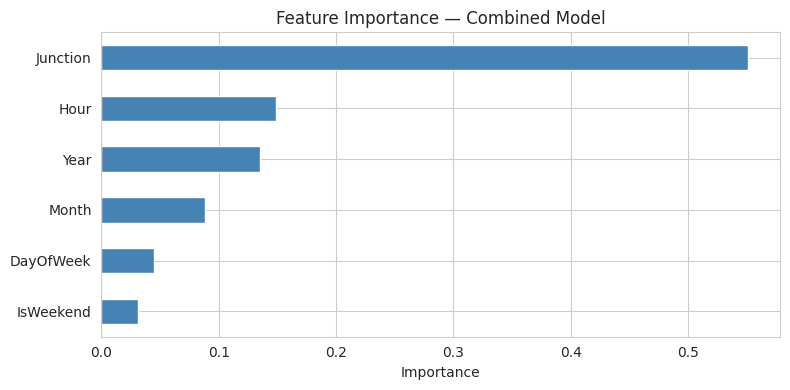

Junction     0.550780
Hour         0.149222
Year         0.135477
Month        0.088209
DayOfWeek    0.044852
IsWeekend    0.031460
dtype: float64


In [ ]:
imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values()

plt.figure(figsize=(8, 4))
imp.plot(kind='barh', color='steelblue')
plt.title('Feature Importance — Combined Model')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('05_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print(imp.sort_values(ascending=False))

**Step 9 — Predicted vs actual**

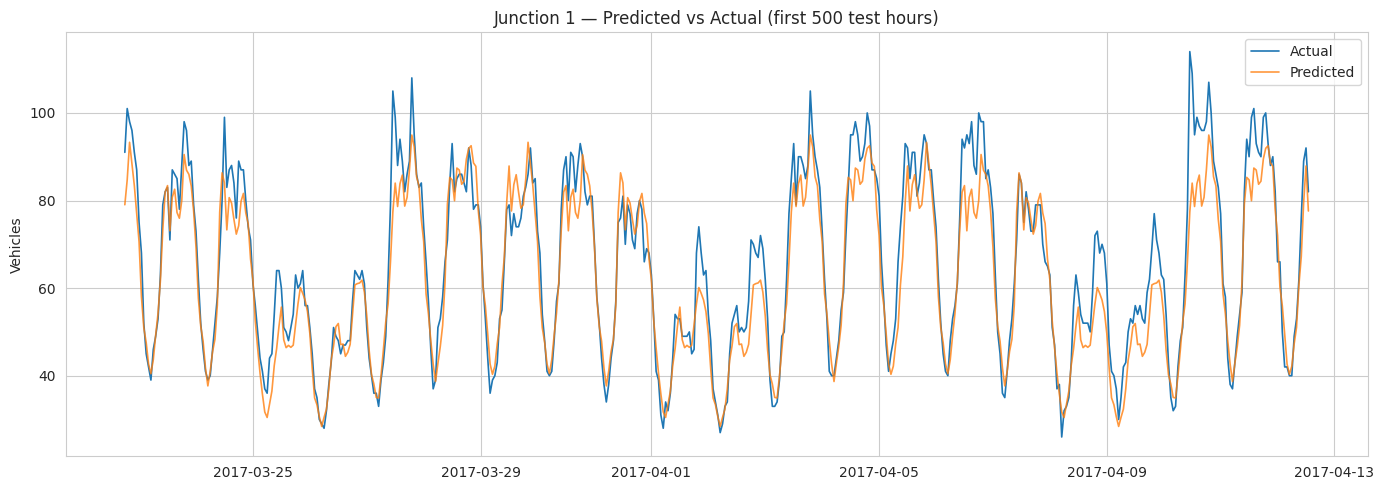

In [ ]:
j = 1     # try each junction
sub = test[test['Junction'] == j].sort_values('DateTime').head(500)

plt.figure(figsize=(14, 5))
plt.plot(sub['DateTime'], sub[TARGET], label='Actual', linewidth=1.2)
plt.plot(sub['DateTime'], sub['Predicted'], label='Predicted', linewidth=1.2, alpha=0.8)
plt.title(f'Junction {j} — Predicted vs Actual (first 500 test hours)')
plt.ylabel('Vehicles')
plt.legend()
plt.tight_layout()
plt.savefig(f'06_pred_vs_actual_junction{j}.png', dpi=120, bbox_inches='tight')
plt.show()

**Step 10 — Inspect the worst misses**

In [ ]:
test['Error'] = (test[TARGET] - test['Predicted']).abs()
worst = test.nlargest(10, 'Error')[['DateTime', 'Junction', TARGET, 'Predicted', 'Error']]
worst

,DateTime,Junction,Vehicles,Predicted,Error
47313,2017-06-22 14:00:00,3,162,22.548794,139.451206
46464,2017-06-13 18:00:00,3,112,20.868306,91.131694
39555,2017-04-02 18:00:00,3,96,17.199690,78.800310
41210,2017-04-20 00:00:00,3,77,16.131048,60.868952
44326,2017-05-22 11:00:00,1,136,77.389917,58.610083
47319,2017-06-22 15:00:00,3,83,24.833214,58.166786
44999,2017-05-29 11:00:00,1,128,77.389917,50.610083
45795,2017-06-06 18:00:00,1,140,89.466440,50.533560
39558,2017-04-02 19:00:00,3,67,17.394920,49.605080
45791,2017-06-06 17:00:00,1,134,84.414071,49.585929


**Step 11 — Save the results**

In [ ]:
per_junction.to_csv('per_junction_metrics.csv', index=False)
comparison.to_csv('model_comparison.csv', index=False)

summary = pd.DataFrame([
    {'Model': 'Baseline (junction-hour average)', 'MAE': round(b_mae, 2), 'RMSE': round(b_rmse, 2)},
    {'Model': 'Random Forest (combined)',         'MAE': round(m_mae, 2), 'RMSE': round(m_rmse, 2)},
])
summary.to_csv('summary_metrics.csv', index=False)
summary

,Model,MAE,RMSE
0,Baseline (junction-hour average),12.02,18.68
1,Random Forest (combined),4.81,7.89
